# **Análisis y modelación utilizando la base de datos IPSA**


A continuación iniciamos el análisis exploratorio de los datos de la base de datos IPSA con el objetivo de conocer la naturaleza de los datos y asi generar 3 clases: 
- Clase 0: "rendimiento bajo"
- Clase 1: "rendimiento medio"
- Clase 2: "rendimiento alto"

Para ello exploraremos 3 métodos para generar las clases. Iniciamos importanto todas las bibliotecas que usaremos en este proyecto.

In [1]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

A continuación importamos la base de datos y visualizamos de forma preliminar la información, verificamos si existe información nula en las variables de clasificación

In [2]:
df = pd.read_excel('BD_IPSA_1940.xlsx')
tch = df['TCH']
sacarosa = df['sacarosa']
print(df.head())
longitud = len(tch)
print('la cantidad de datos es: ', longitud)
#conteo de datos nulos para tch y sacarosa
c = 0
nulos_tch = 0
nulos_sacarosa = 0
p_nulos_tch = []
p_nulos_sacarosa = []
while c < longitud:
    if pd.isna(df.loc[c,'sacarosa']) == True:
        nulos_sacarosa = nulos_sacarosa + 1
        p_nulos_sacarosa = p_nulos_sacarosa + [c]
    if pd.isna(df.loc[c,'TCH']) == True:
        nulos_tch = nulos_tch + 1
        p_nulos_tch = p_nulos_tch + [c]
    c = c + 1

print ('la cantidad de datos nulos de TCH es: ', nulos_tch)
print ('la cantidad de datos nulos de % de sacarosa es: ', nulos_sacarosa) 
        
    


   Unnamed: 0          NOME    FAZ TAL         tipocorte   variedad madurada  \
0          11  AMAIME SILCA  81291  40  Mecanizado Verde  CC01-1940       SI   
1          12  AMAIME SILCA  81291  41  Mecanizado Verde  CC01-1940       SI   
2          13  AMAIME SILCA  81291  41  Mecanizado Verde  CC01-1940       SI   
3          15  AMAIME SILCA  81291  43  Mecanizado Verde  CC01-1940       SI   
4          16  AMAIME SILCA  81291  43  Mecanizado Verde  CC01-1940       SI   

                             producto  dosismad  semsmad  ...  cortes    me  \
0  BONUS 250 EC REGULADOR FISIOLÓGICO       0.8      8.3  ...       4  12.7   
1  BONUS 250 EC REGULADOR FISIOLÓGICO       0.8      6.3  ...       2   7.8   
2  BONUS 250 EC REGULADOR FISIOLÓGICO       0.6      7.9  ...       3   8.8   
3  BONUS 250 EC REGULADOR FISIOLÓGICO       0.8      6.6  ...       1   6.1   
4  BONUS 250 EC REGULADOR FISIOLÓGICO       0.6      8.1  ...       2   7.9   

   vejez  sacarosa  mes  periodo  TCH  lluvi

De la información anterior podemos observar que en el total de 2187 registros no existen datos nulos para ninguna de las variables de clasificación (TCH y sacarosa) que usaremos para determinar las clases. Dado que nuestro objetivo es generar una clasificación entre: rendimiento bajo, rendimiento medio y rendimiento alto, podemos utilizar los siguientes métodos

# **Creación de los umbrales de cada clase** 

Primero analizaremos la distribución de los datos en una análisis exploratorio de las dos variables usadas para determinar las clases: TCH y sacarosa. A continuación podemos ver su distribución en un gráfico de cajas y bigotes, así mismo revisaremos los principales indicadores estadisticos de las dos variables


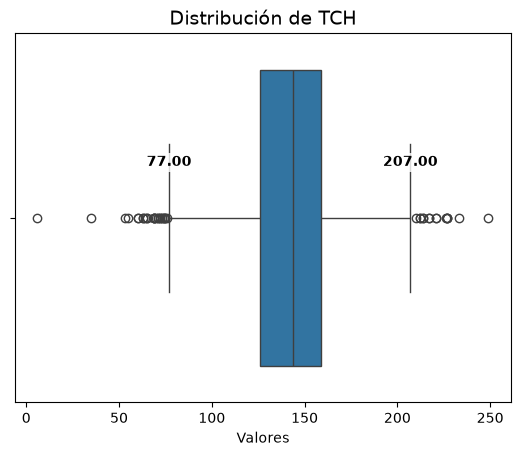

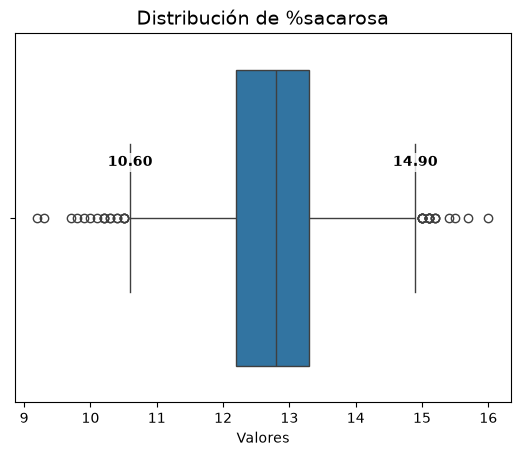

las estadísticas descriptivas de la variables TCH son:  count    2187.000000
mean      142.393233
std        25.838029
min         6.000000
25%       126.000000
50%       144.000000
75%       159.000000
max       249.000000
Name: TCH, dtype: float64
las estadísticas descriptivas de la variables sacarosa son:  count    2187.000000
mean       12.777732
std         0.854397
min         9.200000
25%        12.200000
50%        12.800000
75%        13.300000
max        16.000000
Name: sacarosa, dtype: float64


In [3]:
#grafico de cajas y bigotes para TCH
# gráfico guardándolo en una variable (ax)
#títulos y etiquetas
plt.title('Distribución de TCH', fontsize=14)
plt.xlabel('Valores')
ax = sb.boxplot(x=df['TCH'])

lineas = ax.get_lines()

# 2. EXTRAER DIRECTAMENTE los bigotes que el gráfico ya calculó y dibujó
# Los bigotes son las líneas 0 (inferior) y 1 (superior) de la lista de 'whiskers'

bigote_inf = lineas[0].get_xdata()[1]  # Extremo del bigote izquierdo
bigote_sup = lineas[1].get_xdata()[1]  # Extremo del bigote derecho
#q1 = lineas[2].get_xdata()[0]          # Borde izquierdo de la caja
#q3 = lineas[3].get_xdata()[0]          # Borde derecho de la caja
#mediana = lineas[4].get_xdata()[0]     # Línea central de la mediana

valores_grafico = [bigote_inf, bigote_sup]
# 3. Dibujar las etiquetas de texto sobre el gráfico
for val in valores_grafico:
    ax.text(x=val, y=-0.15, s=f'{val:,.2f}', 
            ha='center', va='center', 
            fontweight='bold', color='black',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

plt.show()

#grafico de cajas y bigotes para SACAROSA
# gráfico guardándolo en una variable (ax)
#títulos y etiquetas
plt.title('Distribución de %sacarosa', fontsize=14)
plt.xlabel('Valores')
ax = sb.boxplot(x=df['sacarosa'])

lineas = ax.get_lines()

# 2. EXTRAER DIRECTAMENTE los bigotes que el gráfico ya calculó y dibujó
# Los bigotes son las líneas 0 (inferior) y 1 (superior) de la lista de 'whiskers'

bigote_inf = lineas[0].get_xdata()[1]  # Extremo del bigote izquierdo
bigote_sup = lineas[1].get_xdata()[1]  # Extremo del bigote derecho
#q1 = lineas[2].get_xdata()[0]          # Borde izquierdo de la caja
#q3 = lineas[3].get_xdata()[0]          # Borde derecho de la caja
#mediana = lineas[4].get_xdata()[0]     # Línea central de la mediana

valores_grafico = [bigote_inf, bigote_sup]
# 3. Dibujar las etiquetas de texto sobre el gráfico
for val in valores_grafico:
    ax.text(x=val, y=-0.15, s=f'{val:,.2f}', 
            ha='center', va='center', 
            fontweight='bold', color='black',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

plt.show()

#estadistica descriptiva de cada variable
print('las estadísticas descriptivas de la variables TCH son: ', df['TCH'].describe())
print('las estadísticas descriptivas de la variables sacarosa son: ', df['sacarosa'].describe())

### **Análisis umbrales de TCH**
- El umbral inferior para definir datos atípicos (outliers) es: 77.0
- El umbral superior para definir datos atípicos (outliers) es: 207.0

No es viable eliminar ni aplanar estos datos atípicos de ninguna forma, estos datos no otorgan ruido sino información real, nuestro método de clasificación debe ser lo suficientemente robusto como para incluirlos y la definición de las categorias debe cumplir las siguientes características:
1. Todos los datos con valor de TCH 77.0 o menos deben ser catalogados en la clase 0.
2. Todos los datos con valor de TCH 207.0 o más deben ser catalogados en la clase 2.



In [4]:
#por buenas practicas realizamos una copia de df para realizar las posteriores modificaciones en el analisis para TCH
#el valor numerico de la fila TCH es 17
df_tch = df.copy()
df_tch = df_tch.sort_values(by='TCH')
j_tch = 17
print (df_tch['TCH'].head(21))
print (df_tch['TCH'].tail(21))


664      6
1118    35
959     53
85      55
90      60
794     60
2182    63
282     63
1587    64
577     65
2176    65
1955    69
1153    69
93      69
158     69
94      70
462     71
810     71
2115    72
967     72
1382    73
Name: TCH, dtype: int64
1200    203
303     204
532     205
919     206
584     206
1398    207
661     210
172     212
1355    212
1485    214
306     214
766     217
1247    217
164     221
895     221
2092    226
379     227
1859    227
1223    227
893     233
765     249
Name: TCH, dtype: int64


#### **Descarte método de los terciles**
Descartamos este método de clasificación para la base de datos basada en TCH ya que no tiene sentido dentro del contexto de negocio asumir que del total de registros la tercera parte son de rendimiento bajo, medio y alto respectivamente. Lo cual significa que si bien es una clasificación conveniente para la aplicación de métodos matemáticos de clasificación, no obedecen a la realidad que se intenta representar. Por tanto descartamos esta aproximación.

Igualmente no consideramos correcto agrupar los datos por frecuencia ya que realmente lo que determina si el rendimiento es alto, medio o bajo no es la frecuancia de los datos, es su valor medible.

#### **Propuesta de método de intervalos iguales con consideraciones**
Proponemos utilizar el método de los intervalos iguales para separar las clases, sin embargo, no es apropiado utilizar de forma directa este método debido a que el valor mínimo y el valor máximo se encuentran muy distantes de sus datos adyacentes. Sin embargo observando tanto la cabeza como la cola de la base de datos ordenada por TCH, podemos observar que no son demasiados los valores demasiado extremos, por tanto es posible construir un nuevo intervalo a partir de un máximo y un mínimo arbitrario con un hyperparámetro que me indica que proporsión omitir de los valores extremos.

Es por ello que proponemos con la modificación mencionada anteriormente calcular los umbrales de TCH para realizar nuestra clasificación. Dado a que se observa que rápidamente los datos empiezan a agruparse, proponemos descartar del cálculo de mínimo y máximo con una proporsión $h=0.05$ arbitraria.

$$rango = \frac{ ValorMaximo - ValorMinimo }{ 3 }$$
donde
$$RendimientoBajo = (-\infty, ValorMinimo + rango]$$
$$RendimientoMedio = (ValorMinimo + rango, ValorMinimo + 2\times rango]$$
$$RendimientoAlto = (ValorMinimo + 2\times rango, \infty)$$

Teniendo en cuenta $h$, para encontrar $ValorMaximo$, $ValorMinimo$ descartamos una proporsión $h$ de los datos de la cabeza y la cola. Esto es, para una base de datos ordenada el indice del valor máximo y mínimo se encuentra de la siguiente manera:

Sea 
$$N: \mbox{tamaño de la población}  $$
$$h \rightarrow [0, 1], \mbox{proporsión de la cabeza y de la cola que se desea descartar}$$

$$i_{min} = round(h \times N)$$
$$i_{max} = round(N- h\times N)$$ 
Donde round es la función de redondeo. Nótese que en caso de no aplicar un ajuste, es decir, $h=0$. Los índices máximos y minimos corresponden con el primer y último dato, es decir el dato $0$ y el dato $N$.


In [40]:
h = 0.05 #0.05% que mencionamos anteriormente
mov_datos = round(longitud * h) #proporsion de datos que voy a ignorar
dato_minimo = df_tch.iloc[mov_datos-1, j_tch]
dato_maximo = df_tch.iloc[longitud-mov_datos-1, j_tch]
rango_tch = (dato_maximo - dato_minimo)/3
bajo = [0, dato_minimo + rango_tch]
medio = [bajo[1], bajo[1] + rango_tch] 
alto = [medio[1], 1000]

c = 0
cats = []
conteo_clases = [0,0,0]
while c < longitud:
    temp = df_tch.iloc[c, j_tch]
    cat_temp =  1
    if temp <= bajo[1]:
        cat_temp = 0
        conteo_clases[0] = conteo_clases[0] + 1
    if temp > alto[0]:
        cat_temp = 2
        conteo_clases[2] = conteo_clases[2] + 1
    cats = cats + [cat_temp]
    c = c + 1
conteo_clases[1] = longitud - conteo_clases[0] - conteo_clases[2]
df_tch['clases'] = cats
print('el intervalo de rendimiento bajo es: ',bajo)
print('el intervalo de rendimiendo medio es: ',medio)
print('el intervalo de rendimiento alto es: ',alto)
print ('la base de datos con la clasificación propuesta muestra la siguiente distribución de clases, desde clase 0 hasta clase 2: ', conteo_clases)
print ('en proporsion las clases se observan de la siguiente manera: ', conteo_clases[0]/longitud,'   ', conteo_clases[1]/longitud, '', conteo_clases[2]/longitud)

el intervalo de rendimiento bajo es:  [0, np.float64(127.0)]
el intervalo de rendimiendo medio es:  [np.float64(127.0), np.float64(155.0)]
el intervalo de rendimiento alto es:  [np.float64(155.0), 1000]
la base de datos con la clasificación propuesta muestra la siguiente distribución de clases, desde clase 0 hasta clase 2:  [581, 938, 668]
en proporsion las clases se observan de la siguiente manera:  0.26566072245084593     0.4288980338363054  0.30544124371284864


Notese que en caso de incrementar el hyperparámetro h, las clases se vuelven cada vez más uniformes. Consideramos que la clasificación propuesta se ajusta a la realidad del negocio donde esperamos que la mayor parte de la producción se agrupe en la calidad comercial o media, así mismo la clasificación planteada es sencilla de modificar en caso que el ingenio dicte un parámetro arbitrario a partir del cual se considerara que hay rendimiento bajo, medio y alto. Es por ello que seleccionamos este criterio de clasificación para determinar las clases.

### **Mención K-means**
El algoritmo k-means establece un número de clases k (en este caso k = 3) donde la sumatoria de todas las distancias a un centroide definido para cada clase es mínima, este algoritmo permite tambien establecer una clasificación para cada clase. Sin embargo sufre también de alta sensibilidad a los datos extremos y no es tan trivial ignorarlos como en el método que utilizamos. Adicionalmente la clasificación resultante puede generar fronteras poco intuitivas de entender para los propósitos del negocio. Si bien es posible aplicarlo, consideramos que la propuesta de clasificación mencionada anteriormente es más apropiada.

## **Conclusión de asignación de clases para TCH**
Consideramos que el método propuesto de intervalor iguales con las consideraciones mencionadas representa apropiadamente los criterios del negocio, tiene en cuenta que en realidad un producto se considera de rendimiento alto, medio o bajo según la medición de sus parámetros apropiados. Dado que estamos clasificando en terminos del TCH, es razonable clasificar deduciendo unos intervalos a partir de la información de la base de datos como lo realizamos en el método propuesto.

Por ello añadimos la clase según el TCH utilizando este proceso, concluyendo así que:
- Si el valor del $TCH \leq 127$, asignamos a la clase 0, la cual corresponde a "rendimiento bajo"
- Si el valor del $127 < TCH \leq 155$, asignamos a la clase 1, la cual corresponde a "rendimiento medio"
- Si el valor del $TCH > 155$, asignamos a la clase 2, la cual corresponde a "rendimiento alto"

Podemos ver a continuación la base de datos de trabajo para TCH con su respectiva clasificación.

In [6]:
print (df_tch[['TCH', 'clases']])


      TCH  clases
664     6       0
1118   35       0
959    53       0
85     55       0
90     60       0
...   ...     ...
379   227       2
1859  227       2
1223  227       2
893   233       2
765   249       2

[2187 rows x 2 columns]


## **Estudio para asignación de clases según sacarosa en caña**
Realizando un estudio similar al del TCH y verificando su grafico de cajas y bigotes, planteamos las siguientes condiciones:
- Los valores de 10.6 o inferiores deben ser categorizados como clase 0 o "rendimiento bajo"
- los valores de 14.9 o superiores deben ser categorizados como clase 2 o "rendimiento alto"

Al igual que para el TCH consideramos que estos valores a pesar de ser considerados valor atípicos no deben ser alterados de ninguna manera ya que representan información de la base de datos que debe ser tenida en cuenta, para ello realizaremos una exploración de la información.

In [7]:
df_sac = df.copy()
df_sac = df_sac.sort_values(by='sacarosa')
j_sac = 14
print (df_sac['sacarosa'].head(21))
print (df_sac['sacarosa'].tail(21))

1182     9.2
1261     9.3
515      9.7
1734     9.8
156      9.9
1749    10.0
1827    10.1
1809    10.2
1793    10.2
721     10.2
1790    10.3
104     10.3
967     10.4
182     10.4
621     10.5
306     10.5
1866    10.5
956     10.5
1491    10.6
1399    10.6
1080    10.7
Name: sacarosa, dtype: float64
1670    14.8
1699    14.9
549     15.0
1792    15.0
1610    15.0
550     15.0
1294    15.0
1009    15.0
111     15.1
580     15.1
109     15.1
864     15.1
1450    15.1
1077    15.1
648     15.2
1007    15.2
1209    15.2
2154    15.4
1286    15.5
576     15.7
736     16.0
Name: sacarosa, dtype: float64


Al observar la base de datos ordenada por sacarosa en caña se observa menor distancia entre los valores extremos, al cuerpo de la base de datos, es decir los datos tienden a estar más agrupados, descartamos el método de los terciles ya que de nuevo no tiene sentido en terminos de negocio determinar que un producto es de alta o baja calidad según la frecuencia de datos, de nuevo lo que determina su calidad es un criterio de un valor medible. 

Por ello proponemos utilizar el mismo método de intervalos iguales, pero podemos utilizarlo con un $h$ muy pequeño o incluso 0, para ello haremos la exploración para realizar la clasificación. 

In [8]:
h = 0.05 #0.050% que mencionamos anteriormente
mov_datos = round(longitud * h) #proporsion de datos que voy a ignorar
dato_minimo = df_sac.iloc[mov_datos-1, j_sac]
dato_maximo = df_sac.iloc[longitud-mov_datos-1,j_sac]
rango_sac = (dato_maximo - dato_minimo)/3
bajo = [0, dato_minimo + rango_sac]
medio = [bajo[1], bajo[1] + rango_sac] 
alto = [medio[1], 1000]

c = 0
cats = []
conteo_clases = [0,0,0]
while c < longitud:
    temp = df_sac.iloc[c, j_sac]
    cat_temp =  1
    if temp <= bajo[1]:
        cat_temp = 0
        conteo_clases[0] = conteo_clases[0] + 1
    if temp > alto[0]:
        cat_temp = 2
        conteo_clases[2] = conteo_clases[2] + 1
    cats = cats + [cat_temp]
    c = c + 1
conteo_clases[1] = longitud - conteo_clases[0] - conteo_clases[2]
df_sac['clases'] = cats
print('el intervalo de rendimiento bajo es: ',bajo)
print('el intervalo de rendimiendo medio es: ',medio)
print('el intervalo de rendimiento alto es: ',alto)
print ('la base de datos con la clasificación propuesta muestra la siguiente distribución de clases, desde clase 0 hasta clase 2: ', conteo_clases)
print ('en proporsion las clases se observan de la siguiente manera: ', conteo_clases[0]/2187,'   ', conteo_clases[1]/2187, '', conteo_clases[2]/2187)

el intervalo de rendimiento bajo es:  [0, np.float64(12.333333333333334)]
el intervalo de rendimiendo medio es:  [np.float64(12.333333333333334), np.float64(13.266666666666667)]
el intervalo de rendimiento alto es:  [np.float64(13.266666666666667), 1000]
la base de datos con la clasificación propuesta muestra la siguiente distribución de clases, desde clase 0 hasta clase 2:  [671, 886, 630]
en proporsion las clases se observan de la siguiente manera:  0.3068129858253315     0.4051211705532693  0.2880658436213992


Si bien no observamos mucha variación en los datos de sacarosa, de la literatura existe una estimación dada por diversos organismos tales como cenicaña que establecen que aproximadamente un porcentaje de sacarosa en caña inferior a 12.5 se considera de baja calidad. Por ello, elevamos un poco el $h=0.05$ en lugar del valor cercano a 0 que consideramos inicialmente. De esta manera el intérvalo central, "rendimiento medio", se achata considerando este dato estimado de la literatura.

## **Conclusión asignación de clases para porcentaje de sacarosa en caña**

Consideramos que el método propuesto de intervalor iguales con las consideraciones mencionadas representa apropiadamente los criterios del negocio, tiene en cuenta que en realidad un producto se considera de rendimiento alto, medio o bajo según la medición de sus parámetros apropiados. Dado que estamos clasificando en terminos de la variable "sacarosa", es razonable clasificar deduciendo unos intervalos a partir de la información de la base de datos como lo realizamos en el método propuesto.

Por ello añadimos la clase según la sacarosa utilizando este proceso, concluyendo así que:

- Si el valor de $sacarosa \leq 12.33$, asignamos a la clase 0, la cual corresponde a "rendimiento bajo"
- Si el valor de $12.33 < sacarosa \leq 13.27$, asignamos a la clase 1, la cual corresponde a "rendimiento medio"
- Si el valor de $sacarosa > 13.27$, asignamos a la clase 2, la cual corresponde a "rendimiento alto"

Podemos ver a continuación la base de datos de trabajo para sacarosa con su respectiva clasificación.

In [9]:
print (df_sac[['sacarosa', 'clases']])

      sacarosa  clases
1182       9.2       0
1261       9.3       0
515        9.7       0
1734       9.8       0
156        9.9       0
...        ...     ...
1209      15.2       2
2154      15.4       2
1286      15.5       2
576       15.7       2
736       16.0       2

[2187 rows x 2 columns]


# **Selección de variables preliminares para TCH y sacarosa**
Verificando las columnas y sus definiciones estudiaremos las variables.

In [10]:
columnas = df.columns
cant_columnas = len(columnas)
c = 0
total_unicos = []
while c < cant_columnas:
    total_unicos =  total_unicos + [df[columnas[c]].nunique()]
    if c > 0:
        print ('la cantidad de datos unicos de', columnas[c], ' es: ', total_unicos[c])
    c =  c + 1


la cantidad de datos unicos de NOME  es:  285
la cantidad de datos unicos de FAZ  es:  285
la cantidad de datos unicos de TAL  es:  273
la cantidad de datos unicos de tipocorte  es:  1
la cantidad de datos unicos de variedad  es:  1
la cantidad de datos unicos de madurada  es:  1
la cantidad de datos unicos de producto  es:  1
la cantidad de datos unicos de dosismad  es:  18
la cantidad de datos unicos de semsmad  es:  150
la cantidad de datos unicos de edad  es:  73
la cantidad de datos unicos de cortes  es:  14
la cantidad de datos unicos de me  es:  99
la cantidad de datos unicos de vejez  es:  202
la cantidad de datos unicos de sacarosa  es:  62
la cantidad de datos unicos de mes  es:  12
la cantidad de datos unicos de periodo  es:  72
la cantidad de datos unicos de TCH  es:  153
la cantidad de datos unicos de lluvias  es:  427
la cantidad de datos unicos de grupo_tenencia  es:  3
la cantidad de datos unicos de pct_diatrea  es:  142


- Las variables NOME, FAZ, TAL son variables de registro, si bien es posible que exista poder clasificador en los indicadores de la finca o lote donde esta el cultivo, es decir: que una finca genera mejores calidades, por cuestiones metodológicas preferimos utilizar variables manipulables, así mismo dado que son variables categoricas, esto incrementaria el tamaño de columnas de la base de datos de forma considerable al incluirse.
- tipocorte, variedad, madurada y producto: son variables que teoricamente tendrían influencia en la clasificación, sin embargo son variables categoricas y existe un solo registro único para cada una de ellas, por tanto no tiene sentido incluirla ya que todos los datos comparten el mismo atributo.
- dosismad: no esperamos que la dosis del madurante influya en el TCH, pero si en la sacarosa.
- semsmad: en el TCH no esperamos que influya, la caña de azucar desde que esta en estado viche hasta que alcanza mejores niveles de maduración no gana peso significativo, dado que TCH es una medida de peso, esperamos que sea poco importante. Sin embargo en la sacarosa es un criterio fuerte de clasificación.
- edad: variable numérica que esperamos que influya en la clasificación de ambos casos.
- cortes: la caña al igual que otros cultivos presenta un comportamiento distinto según la cantidad de cosechas o cortes, es posible que tenga poder de clasificación en ambos modelos.
- ME: creemos que es material extraño, que son elementos ajenos a la caña que no aporta valor tales como hojas secas. Dado que generalmente al medir el TCH se incluye el ME, claramente aporta peso, es decir es directamente una proporsión del TCH, dado que este valor se conoce cuando se conoce el TCH y es una proporsión del mismo, no se puede incluir por data leakage. Así mismo no tiene sentido al analizar sacarosa.
- Vejez: al igual que los cortes, la edad de la caña esperamos que sea influyente.
- mes: el mes de corte, dado que existen distintas condiciones climáticas en el transcurso del año, esta variable puede de forma implicita incluir un poco de información de horas de sol, la cual es fundamental en los cultivos y no esta en la base de datos.
- periodo: año de registro, no tiene sentido incluirla ya que la idea es clasificar el TCH y la sacarosa de acuerdo a variables explicativas.
- lluvias: fundamental en la clasificación, los mm de lluvia durante el cultivo tienen alta influencia teórica sobre los cultivos.
- grupo_tenencia: Es una variable que requiere un poco más de detalle, si bien el tipo de tenencia de un lote no pareciera que tuviera relevancia, es posible argumentar la posibilidad que ciertos grupos de tenencia puedan comprometer la calidad. Dado que no son demasiadas clases esta variable amerita al menos un estudio antes de descartarla.
- pct_diatrea: la diatrea es una plaga que afecta de forma severa a la caña, dado que generalmente los ingenios realizan muestreos sobre sus cultivos, no se considera data leakage y se espera que sea importante tanto para la clasificación por TCH como para la sacarosa.

Por tanto de forma preliminar seleccionamos las siguientes variables para ser estudiadas en cada caso de clasificación.

| Variable | TCH | Sacarosa | Tipo de variable |
| :--- | :--- | :--- | :--- |
| dosismad | NO | SI | numérica |
| semsmad | NO | SI | numérica |
| edad | SI | SI | numérica |
| cortes | SI | SI | numérica |
| ME | DATA LEAKAGE | NO | numérica |
| vejez | SI | SI | numérica |
| mes | SI | SI | categórica |
| periodo | NO | NO | categórica |
| lluvias | SI | SI | numérica |
| grupo_tenencia | PARA ESTUDIO | PARA ESTUDIO | categórica |
| pct_diatrea | SI | SI | numérica |

# **Estudio exploratorio de datos TCH**

A continuación graficamos todas las variables numéricas a explorar con respecto a TCH, para identificar si existe una relación observable.



['edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea']


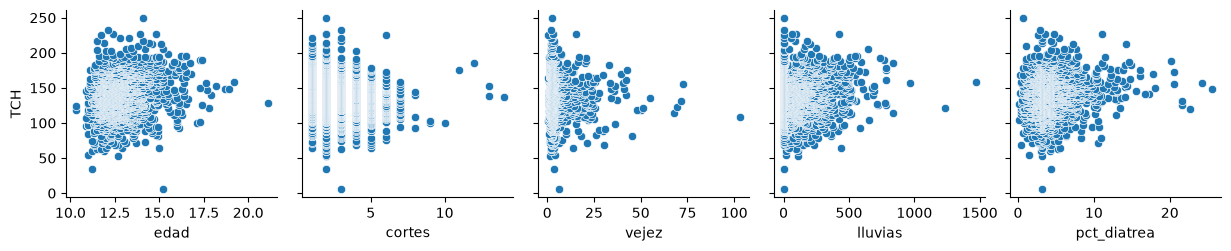

['edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea']


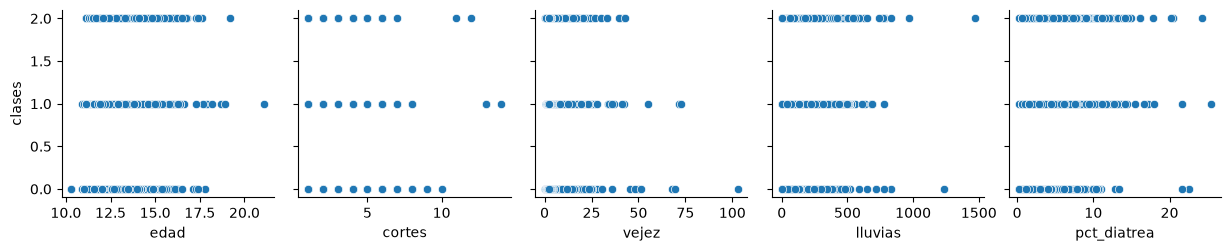

LA MATRIZ DE CORRELACION ES:


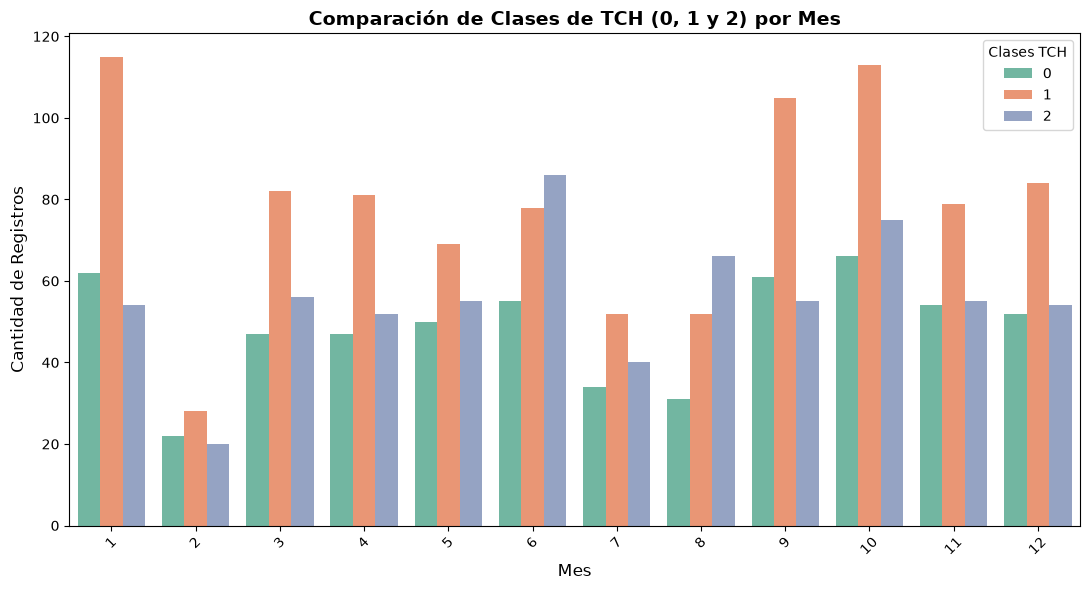

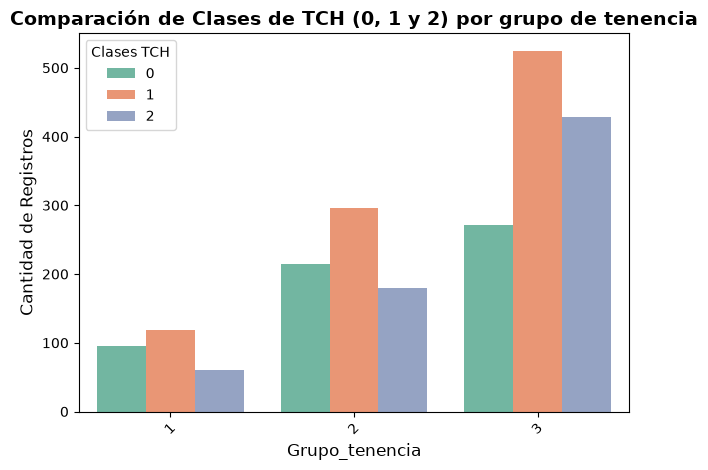

LA MATRIZ DE CORRELACION ES:
                 edad    cortes     vejez   lluvias  pct_diatrea       TCH
edad         1.000000 -0.282470 -0.009623  0.466788     0.091207  0.150832
cortes      -0.282470  1.000000  0.046687 -0.111462    -0.080954 -0.230539
vejez       -0.009623  0.046687  1.000000  0.037850    -0.029799 -0.082230
lluvias      0.466788 -0.111462  0.037850  1.000000     0.030036  0.050599
pct_diatrea  0.091207 -0.080954 -0.029799  0.030036     1.000000  0.105009
TCH          0.150832 -0.230539 -0.082230  0.050599     0.105009  1.000000


In [11]:
#pairplots
objetivo = 'TCH'

columnas_x = ['edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea']
print(columnas_x)
sb.pairplot(
    df_tch, 
    x_vars=columnas_x,          # Todas las demás columnas en el eje X
    y_vars=[objetivo], # Tu columna específica en el eje Y
    kind='scatter'               # Tipo de gráfico (puedes usar 'reg' para incluir línea de regresión)
)

plt.show()


matriz_corr = df_tch[['edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea', 'TCH']].corr()

objetivo = 'clases'

columnas_x = ['edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea']
print(columnas_x)
sb.pairplot(
    df_tch, 
    x_vars=columnas_x,          # Todas las demás columnas en el eje X
    y_vars=[objetivo], # Tu columna específica en el eje Y
    kind='scatter'               # Tipo de gráfico (puedes usar 'reg' para incluir línea de regresión)
)

plt.show()

print('LA MATRIZ DE CORRELACION ES:')
matriz_corr = df_tch[['edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea', 'TCH']].corr()

#--------------------------------------------
# Configuración del tamaño de la figura
plt.figure(figsize=(11, 6))

# Crear el gráfico de barras agrupadas
sb.countplot(
    data=df_tch, 
    x='mes',           # Eje X: Los meses
    hue='clases',      # Las barras se dividen por las clases (0, 1 y 2)
    palette='Set2'     # Paleta de colores atractiva
)

# Estética y títulos
plt.title('Comparación de Clases de TCH (0, 1 y 2) por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.legend(title='Clases TCH', loc='upper right')
plt.xticks(rotation=45) # Rota los meses por si los nombres son largos

plt.tight_layout()
plt.show()


#-------------------------------------------
sb.countplot(
    data=df_tch, 
    x='grupo_tenencia',           # Eje X: Los meses
    hue='clases',      # Las barras se dividen por las clases (0, 1 y 2)
    palette='Set2'     # Paleta de colores atractiva
)

# Estética y títulos
plt.title('Comparación de Clases de TCH (0, 1 y 2) por grupo de tenencia', fontsize=14, fontweight='bold')
plt.xlabel('Grupo_tenencia', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.legend(title='Clases TCH', loc='upper left')
plt.xticks(rotation=45) # Rota los meses por si los nombres son largos

plt.tight_layout()
plt.show()


print('LA MATRIZ DE CORRELACION ES:')
matriz_corr = df_tch[['edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea', 'TCH']].corr()
print(matriz_corr)


### **Variables numéricas**
Primero analizamos las variables numéricas con respecto a la variable numérica TCH, se compara con TCH y no con su clase debido a que su clase es calculada de forma directa con el TCH y es más visible el anáslisis de esta manera. Observando las gráficas no observamos ningún patrón evidente, así mismo la correlación con magnitud más alta es -0.23, que corresponde a la variable cortes. Esto sugiere una relación lineal bastante débil, con las demás variables directamente no se observa ninguna relación lineal. Por lo tanto se incluyen las variables por sugerencia teórica aunque no se observa una relación clara. 

De igual manera se compararon directamente con las clases y tampoco se observa mucho en las gráficas, tal vez exista una relación de clasificación cuando la variable 'vejez' es demasiado grande, en otras palabras, pareciera que cuando la caña es joven no parece haber una clasificación clara, sin embargo cuando la caña envejece se observa que la clasificación tiene a asignarse primero entre la clase 1 y la clase 0 y en los valores más altos en la clase 0, en otras palabras, podría ser que recategorzando esta variable valores superiores a valor determinado que significa vejez en la caña, esta variable tenga poder de categorización para las clases 0 y 1.

### **Variables categóricas**
Teniendo en cuenta que la distribución de clases está asignando el 42% de los datos a la clase 1, es normal que las barras sean más elevadas para esta clase en cada mes, sin embargo, existen meses tales como el mes 6 y el mes 8 donde hay mayor rendimiento, es decir, la mayoría de los datos asignados a ese més fueron de alto rendimiento. Consideramos apropiado incluir esta variable categórica ya que en algunos meses parece presentar un criterio clasificación.

Al observar nuestra variable en duda de grupo_tenencia observamos que aunque no es muy claro, se confirma la sospecha que esta variable debe ser estudiada por un modelo, parece sugerir que el tipo de tenencia de los lotes influye en el rendimiento del TCH, puede ser, aunque esto debe ser confirmado por el ingenio que en algunas formas de tenencia el manejo del terreno sea más laxo o se apliquen algunos criterios diferentes. Por tanto, dado que esta variable no genera data leakage y del análisis preliminar se observa que puede tener poder de clasificación, decidimos incluirla.

### **Conclusiones**
- La variable categórica mes debe ser incluida en el estudio del modelo de clasificación, debido a que se observa una distinción en las clases objetivo para algunas categorias. Sospechamos que esto se debe a que el mes en que se realizó la cosecha trae de forma implicita información climatica, tal como las horas sol. Así mismo es una practica conocida de los ingenios, que trabajan con variedades diseñadas genéticamente para mejorar su producción en ciertos momentos del año, esta información parece estar siendo captada por la variable mes.
- La variable categórica tipo de tenencia, si bien no se pude ubicar un criterio claro teórico que justifique su inclusión, si parece ofrecer criterio de clasificación al observar su comportamiento. Sospechamos que es posible que algunas practicas difieran según la forma de tenencia de los lotes y esto influya en su rendimiento final.
- La variable vejez debe ser recategorizada a una variable que indique si la caña es vieja o no, ya que se observa que en valores donde la caña es vieja, se encuentran principalmente valores de clase 0 o bajo rendimiento.
- Parece existir una relación entre cierta cantidad de cortes y el rendimiento en TCH, proponemos estudiar esta variable para determinar si existen rangos en los cuales puede ser influyente.
- Las variables numéricas no parecen tener una relación clara con la clasificación. Se estudian las variables que según la teoria deben influir tal como lo es la lluvia, , el porcentaje de diatrea. 

## **Estudio exploratorio de los datos sacarosa**


['dosismad', 'semsmad', 'edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea']


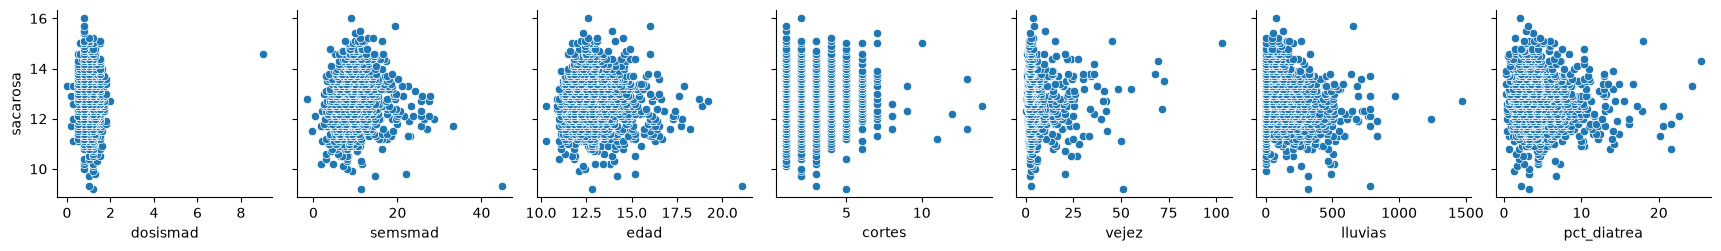

['dosismad', 'semsmad', 'edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea']


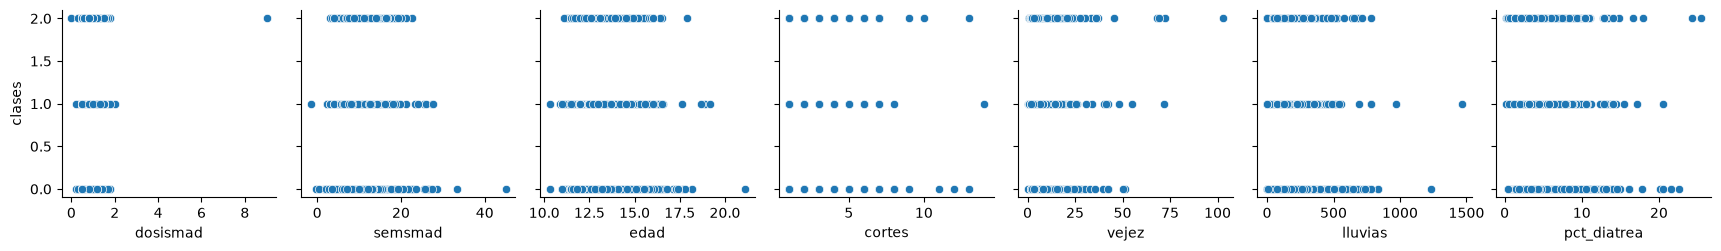

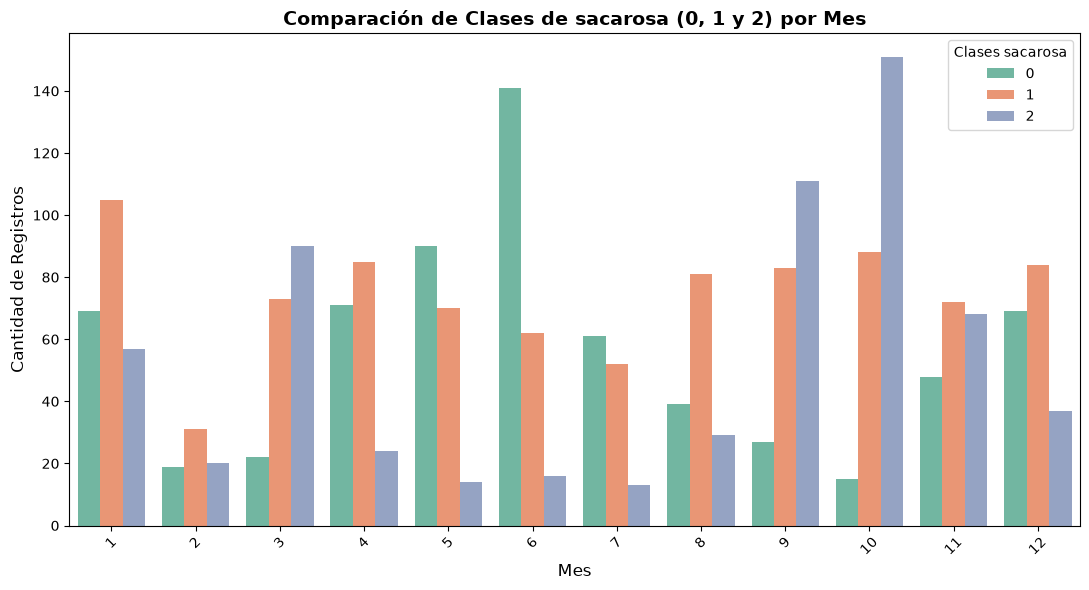

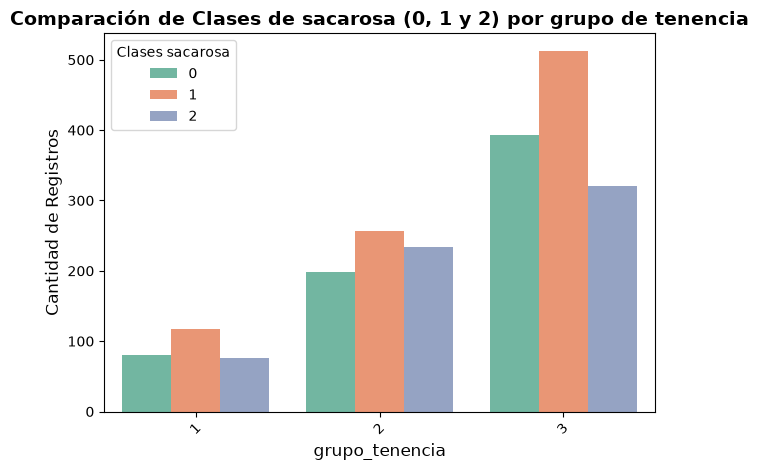

LA MATRIZ DE CORRELACION ES:
             dosismad   semsmad      edad    cortes     vejez   lluvias  \
dosismad     1.000000  0.097175  0.097682 -0.060091  0.109721  0.262238   
semsmad      0.097175  1.000000  0.664796 -0.025624  0.003449  0.440023   
edad         0.097682  0.664796  1.000000 -0.282470 -0.009623  0.466788   
cortes      -0.060091 -0.025624 -0.282470  1.000000  0.046687 -0.111462   
vejez        0.109721  0.003449 -0.009623  0.046687  1.000000  0.037850   
lluvias      0.262238  0.440023  0.466788 -0.111462  0.037850  1.000000   
pct_diatrea -0.031037  0.034587  0.091207 -0.080954 -0.029799  0.030036   
sacarosa    -0.006872  0.092324 -0.043997  0.040351 -0.011720 -0.158616   

             pct_diatrea  sacarosa  
dosismad       -0.031037 -0.006872  
semsmad         0.034587  0.092324  
edad            0.091207 -0.043997  
cortes         -0.080954  0.040351  
vejez          -0.029799 -0.011720  
lluvias         0.030036 -0.158616  
pct_diatrea     1.000000 -0.090487  

In [12]:
#pairplots
objetivo = 'sacarosa'

columnas_x = ['dosismad', 'semsmad', 'edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea']
print(columnas_x)
sb.pairplot(
    df_sac, 
    x_vars=columnas_x,          # Todas las demás columnas en el eje X
    y_vars=[objetivo], # Tu columna específica en el eje Y
    kind='scatter'               # Tipo de gráfico (puedes usar 'reg' para incluir línea de regresión)
)

plt.show()


objetivo = 'clases'

columnas_x = ['dosismad', 'semsmad', 'edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea']
print(columnas_x)
sb.pairplot(
    df_sac, 
    x_vars=columnas_x,          # Todas las demás columnas en el eje X
    y_vars=[objetivo], # Tu columna específica en el eje Y
    kind='scatter'               # Tipo de gráfico (puedes usar 'reg' para incluir línea de regresión)
)

plt.show()

plt.figure(figsize=(11, 6))

# Crear el gráfico de barras agrupadas
sb.countplot(
    data=df_sac, 
    x='mes',           # Eje X: Los meses
    hue='clases',      # Las barras se dividen por las clases (0, 1 y 2)
    palette='Set2'     # Paleta de colores atractiva
)

# Estética y títulos
plt.title('Comparación de Clases de sacarosa (0, 1 y 2) por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.legend(title='Clases sacarosa', loc='upper right')
plt.xticks(rotation=45) # Rota los meses por si los nombres son largos

plt.tight_layout()
plt.show()


#--------------------
sb.countplot(
    data=df_sac, 
    x='grupo_tenencia',           # Eje X: Los meses
    hue='clases',      # Las barras se dividen por las clases (0, 1 y 2)
    palette='Set2'     # Paleta de colores atractiva
)

# Estética y títulos
plt.title('Comparación de Clases de sacarosa (0, 1 y 2) por grupo de tenencia', fontsize=14, fontweight='bold')
plt.xlabel('grupo_tenencia', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.legend(title='Clases sacarosa', loc='upper left')
plt.xticks(rotation=45) # Rota los meses por si los nombres son largos

plt.tight_layout()
plt.show()




print('LA MATRIZ DE CORRELACION ES:')
matriz_corr = df_sac[['dosismad', 'semsmad', 'edad', 'cortes', 'vejez', 'lluvias', 'pct_diatrea', 'sacarosa']].corr()
print (matriz_corr)


### **Variables numéricas**
Primero analizamos las variables numéricas con respecto a la variable numérica sacarosa, se compara con sacarosa y no con su clase debido a que su clase es calculada de forma directa con el valor de sacarosa y es más visible el anáslisis de esta manera. Observando las gráficas no observamos ningún patrón evidente, así mismo la correlación con magnitud más alta es -0.15, que corresponde a la variable lluvias. Este valor no muestra una relación lineal con la variable a explicar, por tanto, no se observa relación lineal ni evidente de otro tipo entre las variables numéricas y la sacarosa de la caña.

De igual manera se compararon directamente con las clases y tampoco se observa mucho en las gráficas, tal vez exista una relación de clasificación cuando la variable 'vejez' es demasiado grande, en otras palabras, pareciera que cuando la caña es joven no parece haber una clasificación clara, sin embargo cuando la caña envejece se observa que la clasificación tiene a asignarse primero entre la clase 1 y la clase 2 y en los valores más altos en la clase 2, en otras palabras, podría ser que recategorzando esta variable valores superiores a valor determinado que significa vejez en la caña, esta variable tenga poder de categorización para las clases 1 y 2. Esta sospecha se refuerza por medio de la teoría de la senescencia de una planta que establece una relación entre la vejez y la sacarosa. 

### **Variables categóricas**
Teniendo en cuenta que la distribución de clases está asignando el 40.5% de los datos a la clase 1, es normal que las barras sean más elevadas para esta clase en cada mes, sin embargo, existen meses tales como el mes 6, el mes 9 y el mes 10. Observamos que en el mes 6 la gran mayoria de la caña es de rendimiento bajo o clase 0, mientras que en el mes 9 y 10 observamos que se concentra la caña de mayor rendimiento. Validamos la sospecha que el mes esta aportando información con criterio de clasificación, sospechamos que aporta información implicita climática tal como puede ser las horas sol. Por tanto es una variable fundamental a incluir

Al observar nuestra variable en duda de grupo_tenencia observamos que aunque no es muy claro, se confirma la sospecha que esta variable debe ser estudiada por un modelo, parece sugerir que el tipo de tenencia de los lotes influye en el rendimiento de la sacarosa, puede ser, aunque esto debe ser confirmado por el ingenio que en algunas formas de tenencia el manejo del terreno sea más laxo o se apliquen algunos criterios diferentes. Por tanto, dado que esta variable no genera data leakage y del análisis preliminar se observa que puede tener poder de clasificación, decidimos incluirla.

### **Conclusiones**
- La variable categórica mes debe ser incluida en el estudio del modelo de clasificación, debido a que se observa una distinción en las clases objetivo para algunas categorias. Sospechamos que esto se debe a que el mes en que se realizó la cosecha trae de forma implicita información climatica, tal como las horas sol. Así mismo es una practica conocida de los ingenios, que trabajan con variedades diseñadas genéticamente para mejorar su producción en ciertos momentos del año, esta información parece estar siendo captada por la variable mes.
- La variable categórica tipo de tenencia, si bien no se pude ubicar un criterio claro teórico que justifique su inclusión, si parece ofrecer criterio de clasificación al observar su comportamiento. Sospechamos que es posible que algunas practicas difieran según la forma de tenencia de los lotes y esto influya en su rendimiento final.
- La variable vejez debe ser recategorizada a una variable que indique si la caña es vieja o no, ya que se observa que en valores donde la caña es vieja, se encuentran principalmente valores de clase 2 o alto rendimiento.
- Las variables numéricas no parecen tener una relación clara con la clasificación. Se estudian las variables que según la teoria deben influir tal como lo es la lluvia, la dosis de madurante, las semanas de maduración, el porcentaje de diatrea. No incluiremos ni la edad, ni los cortes ya que no se observa poder de clasificación en estas variables.

## **Sobre las lluvias**
En la clasificación de ambas variables: TCH y sacarosa, no parece existir una relación con las lluvias según lo observado. Sin embargo teniendo en cuenta el conocimiento sobre los cultivos, este es un factor altamente influyente, por ello analizaremos los registros de lluvia con mayor detalle.

In [37]:
#conteo de datos nulos para lluvias
c = 0
nulos_lluvia = 0
p_nulos_lluvia = []
j_lluvias = df.columns.get_loc('lluvias')
    
while c < longitud:
    if df.iloc[c, j_lluvias] == 0:
        nulos_lluvia = nulos_lluvia + 1
        p_nulos_lluvia = p_nulos_lluvia + [c]
    c = c + 1

print('la cantidad de datos con lluvias = 0 es: ', nulos_lluvia)
print('proporsion de datos con lluvia = 0 es: ', nulos_lluvia/longitud)




la cantidad de datos con lluvias = 0 es:  685
proporsion de datos con lluvia = 0 es:  0.31321444901691814


Observamos que casi la tercera parte de los datos marca que no existieron lluvias durante todo el cultivo, si bien esto es posible ya que existen tiempos de sequía. Teniendo en cuenta el comportamiento del clima en el Valle del Cauca, es poco probable.

Por tanto vamos a suponer que al menos una parte de esos registros que marcan la cantidad de lluvia en 0, corresponden a datos faltantes. A continuación exploraremos si a partir de la base de datos proporsionada por el ingenio "HISTORICO_SUERTES". Es posible reducir la cantidad de datos nulos y así conocer con mayor precisión una de las variables climáticas fundamentales.

Nombre  ------- NOME
Período ------- periodo
TCH ----------- TCH

In [49]:
#dado que la base de datos es muy pesada, la seccion donde se carga la base de datos del resto del analisis
df_suertes = pd.read_excel('HISTORICO_SUERTES.xlsx')
#print(df_suertes.head())
print('lectura del archivo suertes exitosa!')


   Período  Hacienda             Nombre  Zona  Tenencia Suerte       Suelo  \
0   201701     80493          LA CONCHA  IP02      51.0   002A   CANTARINA   
1   201701     81284    UKRANIA INCAUCA  IP05      81.0   039B         NaN   
2   201701     80203      EL AMPARO SAA  IP05      31.0    007  CORINTIAS    
3   201701     81380  SAN JUDAS INCAUCA  IP05      82.0   013A         NaN   
4   201701     80298               JAVA  IP06      31.0   025A     GALPON    

   Area Neta  Dist Km   Variedad  ...  Humedad Rel Media Ciclo  \
0       6.00      4.3    CC85-92  ...                      NaN   
1       1.45      NaN    CC85-92  ...                      NaN   
2       8.24     23.0  CC01-1228  ...                      NaN   
3       1.05     66.5  CC01-1940  ...                      NaN   
4       4.53     17.0  RB73-2223  ...                      NaN   

  Oscilacion Temp Med 0-3 Oscilacion Temp Ciclo Sum Oscilacion Temp Ciclo  \
0                     NaN                   NaN          

In [50]:
columnas_suertes = df_suertes.columns
print(columnas_suertes)
print(columnas)
print(df.head())

Index(['Período', 'Hacienda', 'Nombre', 'Zona', 'Tenencia', 'Suerte', 'Suelo',
       'Area Neta', 'Dist Km', 'Variedad', 'Cod.Estado #', 'Cod.Estado',
       'F.Siembra', 'D.S.', 'Ult.Riego', 'Edad Ult Cos', 'F.Ult.Corte',
       'Destino 1=Semilla', 'Cod. T.Cultivo', 'Cultivo', 'Fec.Madur.',
       'Producto', 'Dosis Madurante', 'Semanas mad.', 'TonUltCorte', 'TCH',
       'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', 'Sac.Caña Precosecha',
       'Edad.Precosecha', '%Sac.Caña', '%Sac.Muestreadora', '%ATR', 'KATRHM',
       '%Fibra Caña', '%AR Jugo', '%ME Min', '%ME Veg', '%ME Tot', 'Brix',
       'Pureza', 'Vejez', 'Tipo Quema', 'T.Corte', 'Cerca de', 'Cosechó',
       'Num.Riegos', 'M3 Riego', 'DDUlt.Riego', 'Lluvias (2 Meses Ant.)',
       'Lluvias Ciclo', 'Lluvias 0 -3', 'Lluvias tres a seis',
       'Lluvias seis a nueve', 'Luvias 9 -FC', '%Infest.Diatrea',
       'Fosfato Jugo', 'Fert.Nitrogen.', 'Urea 46%', 'MEZ', 'Boro Granul.',
       'MicroZinc', 'NITO_XTEND', 'Sul.Amonio', 

Verificando las columnas, observamos que existen algunas columnas en común:
| Columna Suertes | Columna IPSA |
| :--- | :--- |
| Nombre | NOME |
| TCH | TCH |
| %Sac.Caña | sacarosa |
| Período | periodo | 

Dado que nuestro interes es conocer si existen casos donde en la base de datos IPSA el registro 'lluvias = 0', compararemos asociada de lluvias en la base de datos de 'HISTORICO_SUERTES'. Para ello construiremos una prueba piloto donde igualamos los valores conocidos y estudiamos la información de lluvias de la base de datos más extensa.


# **NO CORRER EL SIGUIENTE CODIGO, CORRESPONDE A LA CREACION DE UNA BASE DE DATOS ENRIQUECIDA Y TARDA MAS DE 30 MINUTOS EN TERMINAR, LA BASE DE DATOS HA SIDO YA ALMACENADA Y SE UTILZARA A CONTINUACION**

In [117]:
# c = 0
# piloto = 30 #estudiaremos 30 datos para poder visualizar
# #creo a continuacion las listas de informacion
# ndf_lluvias = df[['NOME', 'FAZ', 'periodo', 'TCH', 'sacarosa', 'edad', 'lluvias']]

# #ahora localizo sus equivalentes en suertes y hago los vectores de equivalencia
# j_nome = [df.columns.get_loc('NOME'), df_suertes.columns.get_loc('Nombre')]
# j_faz = [df.columns.get_loc('FAZ'), df_suertes.columns.get_loc('Hacienda')]
# j_periodo = [df.columns.get_loc('periodo'), df_suertes.columns.get_loc('Período')]
# j_tch = [df.columns.get_loc('TCH'), df_suertes.columns.get_loc('TCH')]
# j_sac = [df.columns.get_loc('sacarosa'), df_suertes.columns.get_loc('%Sac.Caña')]

# j_lluvias =  df_suertes.columns.get_loc('Lluvias Ciclo')
# #debo verificar con que datos de lluvia coinciden los de la base IPSA
# lluvia_ciclo = []
# lluvia_03 = []
# lluvia_36 = []
# lluvia_69 = []
# lluvia_9fc = []
# longitud_suertes = len(df_suertes['TCH'])
# no_coincide = 0
# indice_suertes = [] #aqui registro todos los indices de coindencia para no tener que volver a buscar

# while c < longitud:
#     i = 0
#     temp_faz = df.iloc[c,j_faz[0]]
#     temp_periodo = df.iloc[c,j_periodo[0]]
#     temp_tch = df.iloc[c,j_tch[0]]
#     coincidio = 0 #boton para saber si hay o no hay coincidencia, empieza sin coincidencia
#     while i < longitud_suertes:
#         temp_fazs = df_suertes.iloc[i,j_faz[1]]
#         temp_periodos = df_suertes.iloc[i,j_periodo[1]]
#         temp_tchs = round(df_suertes.iloc[i, j_tch[1]], 0)
#         if temp_faz == temp_fazs:
#             #print('coincidencia en faz!')
#             if temp_periodo == temp_periodos:
#                 #print('coincidencia en periodo!')
#                 if temp_tch == temp_tchs:
#                     lluvia_ciclo = lluvia_ciclo + [df_suertes.iloc[i,j_lluvias]]
#                     lluvia_03 = lluvia_03 + [df_suertes.iloc[i,j_lluvias + 1]]
#                     lluvia_36 = lluvia_36 + [df_suertes.iloc[i,j_lluvias + 2]]
#                     lluvia_69 = lluvia_69 + [df_suertes.iloc[i,j_lluvias + 3]]
#                     lluvia_9fc = lluvia_9fc + [df_suertes.iloc[i,j_lluvias + 4]]
#                     indice_suertes = indice_suertes + [i]
#                     i = i + longitud_suertes
#                     coincidio = 1 #aprieta el boton y lo vuelve 1 si hay coincidencia
#                     print('coincidencia TOTAL!')
#         i = i + 1
#     if coincidio == 0: #si no hubo coincidencia rellena con ceros para mantener consistencia
#         lluvia_ciclo = lluvia_ciclo + [0]
#         lluvia_03 = lluvia_03 + [0]
#         lluvia_36 = lluvia_36 + [0]
#         lluvia_69 = lluvia_69 + [0]
#         lluvia_9fc = lluvia_9fc + [0]
#         indice_suertes = indice_suertes + [-1]
#         no_coincide = no_coincide + 1
        
#     c = c + 1
#     print(c)

# ndf_lluvias['lluvia_ciclo'] = lluvia_ciclo
# ndf_lluvias['lluvia_0-3'] = lluvia_03
# ndf_lluvias['lluvia_3-6'] = lluvia_36
# ndf_lluvias['lluvia_6-9'] = lluvia_69
# ndf_lluvias['lluvia_9-fc'] = lluvia_9fc

# #print(ndf_lluvias.head())

# # 'Lluvias (2 Meses Ant.)',
# #       'Lluvias Ciclo', 'Lluvias 0 -3', 'Lluvias tres a seis',
# #       'Lluvias seis a nueve', 'Luvias 9 -FC'





coincidencia TOTAL!
1
coincidencia TOTAL!
2
coincidencia TOTAL!
3
coincidencia TOTAL!
4
coincidencia TOTAL!
5
coincidencia TOTAL!
6
coincidencia TOTAL!
7
coincidencia TOTAL!
8
coincidencia TOTAL!
9
coincidencia TOTAL!
10
coincidencia TOTAL!
11
coincidencia TOTAL!
12
coincidencia TOTAL!
13
coincidencia TOTAL!
14
coincidencia TOTAL!
15
coincidencia TOTAL!
16
coincidencia TOTAL!
17
coincidencia TOTAL!
18
coincidencia TOTAL!
19
coincidencia TOTAL!
20
coincidencia TOTAL!
21
coincidencia TOTAL!
22
coincidencia TOTAL!
23
coincidencia TOTAL!
24
coincidencia TOTAL!
25
coincidencia TOTAL!
26
coincidencia TOTAL!
27
coincidencia TOTAL!
28
coincidencia TOTAL!
29
coincidencia TOTAL!
30
coincidencia TOTAL!
31
coincidencia TOTAL!
32
coincidencia TOTAL!
33
coincidencia TOTAL!
34
coincidencia TOTAL!
35
coincidencia TOTAL!
36
coincidencia TOTAL!
37
coincidencia TOTAL!
38
39
coincidencia TOTAL!
40
coincidencia TOTAL!
41
coincidencia TOTAL!
42
43
coincidencia TOTAL!
44
coincidencia TOTAL!
45
coincidencia T

In [118]:
# #el problema existe en el indice 39, o sea c =  38
# ndf_lluvias['indice_coincidencia'] = indice_suertes


In [123]:
# ndf_lluvias.head()
# ndf_lluvias.to_excel('df_unido_lluvias.xlsx', index=False)

[np.int64(80493), np.int64(81284), np.int64(80203), np.int64(81380), np.int64(80298), np.int64(80328), np.int64(80194), np.int64(80203), np.int64(80942), np.int64(81311), np.int64(80342), np.int64(80131), np.int64(81268), np.int64(81379), np.int64(81275), np.int64(81311), np.int64(80298), np.int64(80274), np.int64(80493), np.int64(80328), np.int64(80203), np.int64(81142), np.int64(80342), np.int64(80493), np.int64(80108), np.int64(80517), np.int64(80134), np.int64(80123), np.int64(80426), np.int64(80134), np.int64(80517), np.int64(80426), np.int64(81119), np.int64(80298), np.int64(80298), np.int64(80430), np.int64(80505), np.int64(80116), np.int64(80546), np.int64(80498), np.int64(80944), np.int64(80430), np.int64(80116), np.int64(80505), np.int64(80498), np.int64(80426), np.int64(80340), np.int64(80505), np.int64(80156), np.int64(81056), np.int64(80498), np.int64(80346), np.int64(80340), np.int64(80505), np.int64(80116), np.int64(80944), np.int64(80228), np.int64(80944), np.int64(8049